<a href="https://colab.research.google.com/github/lirazshimon11/Data-Science-Course---Assignments/blob/main/%D7%A2%D7%91%D7%95%D7%93%D7%AA_%D7%91%D7%99%D7%AA_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

שם הסטודנט: לירז שמעון
ת.ז: 326720505

In [1]:
!kaggle datasets download wyattowalsh/basketball
!unzip basketball.zip

Dataset URL: https://www.kaggle.com/datasets/wyattowalsh/basketball
License(s): CC-BY-SA-4.0
100% 697M/697M [00:08<00:00, 86.8MB/s]

Archive:  basketball.zip
  inflating: csv/common_player_info.csv  
  inflating: csv/draft_combine_stats.csv  
  inflating: csv/draft_history.csv   
  inflating: csv/game.csv            
  inflating: csv/game_info.csv       
  inflating: csv/game_summary.csv    
  inflating: csv/inactive_players.csv  
  inflating: csv/line_score.csv      
  inflating: csv/officials.csv       
  inflating: csv/other_stats.csv     
  inflating: csv/play_by_play.csv    
  inflating: csv/player.csv          
  inflating: csv/team.csv            
  inflating: csv/team_details.csv    
  inflating: csv/team_history.csv    
  inflating: csv/team_info_common.csv  
  inflating: nba.sqlite              


In [2]:
# here are all the imports I used in this file:
import pandas as pd
import os
import datetime
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

In [45]:
df = pd.read_csv("csv/game.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65698 entries, 0 to 65697
Data columns (total 55 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   season_id               65698 non-null  int64  
 1   team_id_home            65698 non-null  int64  
 2   team_abbreviation_home  65698 non-null  object 
 3   team_name_home          65698 non-null  object 
 4   game_id                 65698 non-null  int64  
 5   game_date               65698 non-null  object 
 6   matchup_home            65698 non-null  object 
 7   wl_home                 65696 non-null  object 
 8   min                     65698 non-null  int64  
 9   fgm_home                65685 non-null  float64
 10  fga_home                50251 non-null  float64
 11  fg_pct_home             50208 non-null  float64
 12  fg3m_home               52480 non-null  float64
 13  fg3a_home               47015 non-null  float64
 14  fg3_pct_home            46624 non-null

**------------------------ 2.2 ------------------------**

**data source:**
kaggle. **bold text**

**Purpose of collection:**
To enable analysis of NBA game statistics. This data can be used to predict future game results, identify tendencys, etc.

**The data source:**
The dataset is published by Wyatt Walsh
But the data was originally pulled from the league's official database - stats.nba.com

**Personal knowledge of the field:**
Watching NBA games in recent years, mainly Golden State Warriors games.


In [46]:
print("------------------------------------------------ Q3 ------------------------------------------------")

print("------------------------ 3.1 File Analysis ------------------------")

file_size_mb = os.path.getsize('csv/game.csv') / (1024 * 1024)
print(f"file size: {file_size_mb:.2f} MB")  # 2f means 2 digits after the main number.
print(f"format: CSV")  # obviously we know the file format by looking at the file path...

print("\n------------------------ 3.2 data structure ------------------------")

df = pd.read_csv('csv/game.csv')
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print(f"\nColumn names: {list(df.columns)}")
print(f"\nData types:\n{df.dtypes.value_counts()}")
print("\n--- Index Analysis ---")
# 1. Is the current default index unique?
# currently it's the default, which means: 0,1,2,3,.......
print(f"Is current index unique? {df.index.is_unique}") # the index (number) in unique because each index appears only once..
# 2. Is the meaningful ID column (game_id) unique?
print(f"Is game_id (Meaningful ID) unique? {df['game_id'].is_unique}")
print(f"Is game_date (Meaningful ID) unique? {df['game_date'].is_unique}")

------------------------------------------------ Q3 ------------------------------------------------
------------------------ 3.1 File Analysis ------------------------
file size: 19.37 MB
format: CSV

------------------------ 3.2 data structure ------------------------
Number of rows: 65698
Number of columns: 55

Column names: ['season_id', 'team_id_home', 'team_abbreviation_home', 'team_name_home', 'game_id', 'game_date', 'matchup_home', 'wl_home', 'min', 'fgm_home', 'fga_home', 'fg_pct_home', 'fg3m_home', 'fg3a_home', 'fg3_pct_home', 'ftm_home', 'fta_home', 'ft_pct_home', 'oreb_home', 'dreb_home', 'reb_home', 'ast_home', 'stl_home', 'blk_home', 'tov_home', 'pf_home', 'pts_home', 'plus_minus_home', 'video_available_home', 'team_id_away', 'team_abbreviation_away', 'team_name_away', 'matchup_away', 'wl_away', 'fgm_away', 'fga_away', 'fg_pct_away', 'fg3m_away', 'fg3a_away', 'fg3_pct_away', 'ftm_away', 'fta_away', 'ft_pct_away', 'oreb_away', 'dreb_away', 'reb_away', 'ast_away', 'stl_away

**------------------------ 3.1 ------------------------**

**File size:**
19.37 MB

**Format:**
CSV

**Date of creation:**
The exact date of creation of the database is not specified, but it can be assumed that it was built on the basis of historical data collected over time from NBA sources..

**Purpose of the data:**
Detailed documentation of league game statistics for the purpose of performance analysis, historical documentation, etc. It was noted that people used this data for the following purposes: learning, research, applications, and machine learning.

**------------------------ 3.2 ------------------------**

**Number of rows and columns:**
65,698 rows
55 columns

**The column names, do they make sense and what can we learn from them?**
The names are very clear and make sense. You can see that there is a really convenient division – for every data of the home team with the suffix home, there is a counterpart for the away team with the suffix away. Because of this structure, it is easy to understand that each row describes one complete game between two teams.

**Data types and what type of data they are. Are there any insights about these?**
Most of the columns are numeric – integers and decimal fractions – which makes sense since we are dealing with a sport association.. There are about 10 columns of text. The most important insight here is that the date column- game_date, currently appears as plain text and not as a time format, so I might need to fix it, in case I analyse by time.

**Index analysis:**
I checked the code and the existing index is simply the normal numbering that Python gives -0, 1, 2 and so on... This numbering is unique because each number appears once, but it has no meaning in terms of the data itself. Columns that are supposed to have meaning – like the game_id or game_date – turned out to be not unique because they have duplicates. So right now we don’t have an index that really represents anything.

**Discussion:**

**Was the data collected for research or operational purposes? What biases might be present?**
This data was collected primarily for the operation of the league – for monitoring, broadcasting and the betting industry. No research experiment was conducted under laboratory conditions. Because this is operational data, there may be biases:

1. There is a crew that records certain data such as assists and blocks, and it is known that sometimes they have a tendency to favor the home team/their favorite team - a little more.

2. The data goes back many years and the rules of the game have changed. For example, the three point line was only introduced in 1979, so comparing games from the 1970s to today will create a distortion in the data. Furthermore, even when comparing modern games to the early years immediately following the introduction of the three point line, the data remains heavily biased. The style of play, strategic focus, and frequency of three point shots were entirely different back then, making a direct comparison to the modern era's heavy reliance on the three point shot is inaccurate.

In [6]:
print("------------------------------------------------ Q4 ------------------------------------------------")

print("------------------------ 4.1 Missing Values ------------------------")

missing_cols = df.isnull().sum()
missing_cols = missing_cols[missing_cols > 0].sort_values(ascending=False)
print(f"Columns with missing data:\n{missing_cols}")

print("\n------------------------ 4.2 Duplicates ------------------------")

full_dups = df.duplicated().sum()
print(f"Full duplicate rows: {full_dups}")
subset_dups = df.duplicated(subset=['game_id']).sum()
print(f"Rows with duplicated game_id: {subset_dups}")

print("\n------------------------ 4.3 Suspicious Values ------------------------")

# Check for impossible shooting stats
impossible_shooting = (
    (df['fgm_home'] > df['fga_home']) | (df['fgm_away'] > df['fga_away']) |
    (df['fg3m_home'] > df['fg3a_home']) | (df['fg3m_away'] > df['fg3a_away']) |
    (df['ftm_home'] > df['fta_home']) | (df['ftm_away'] > df['fta_away'])).sum()
print(f"Games with more makes than attempts: {impossible_shooting}")

wrong_min_count = (df['min'] < 240).sum()  # checking for impossible amount of min count in a game
print(f"Number of games with invalid total minutes: {wrong_min_count}")

invalid_pct = (
    (df['fg_pct_home'] > 1.0) | (df['fg_pct_home'] < 0) |
    (df['fg_pct_away'] > 1.0) | (df['fg_pct_away'] < 0)).sum()
print(f"Games with percentages > 100% or < 0%: {invalid_pct}")

display(df.describe()) # checking for values placeholders # checking for values placeholders

# Check for negative values (*excluding* plus_minus columns which can be negative)
numeric_cols = df.select_dtypes(include='number').columns
cols_no_pm = [col for col in numeric_cols if 'plus_minus' not in col]
negatives_count = (df[cols_no_pm] < 0).sum().sum()
print(f"Total negative values in non-plus/minus columns: {negatives_count}")

# Check for highly unlikely zeros in major team stats (points, rebounds, assists)
unlikely_zeros = (
    (df['pts_home'] == 0) | (df['pts_away'] == 0) |
    (df['reb_home'] == 0) | (df['reb_away'] == 0) |
    (df['ast_home'] == 0) | (df['ast_away'] == 0)).sum()
print(f"Games with unlikely zero team stats (points, rebounds, assists): {unlikely_zeros}")

print("\n------------------------ 4.4 Cardinality ------------------------")

# Calculate the number of unique values for each column
unique_counts = df.nunique()
# 1. Identify columns with zero variance (exactly 1 unique value)
single_value_cols = unique_counts[unique_counts == 1]
print(f"Columns with exactly 1 unique value: {single_value_cols}")
# 2. Identify columns with very high cardinality (e.g., identifiers like IDs)
# Checking for columns where unique values exceed 60,000 (close to the total row count)
high_card_cols = unique_counts[unique_counts > 60000]
print(f"\nColumns with very high cardinality:\n{high_card_cols}")

------------------------------------------------ Q4 ------------------------------------------------
------------------------ 4.1 Missing Values ------------------------
Columns with missing data:
fg3_pct_home    19074
dreb_home       18999
dreb_away       18998
fg3_pct_away    18962
oreb_home       18936
oreb_away       18936
stl_away        18849
stl_home        18849
tov_away        18685
tov_home        18684
fg3a_away       18683
fg3a_home       18683
blk_home        18626
blk_away        18625
ast_home        15805
ast_away        15801
reb_home        15729
reb_away        15725
fg_pct_home     15490
fg_pct_away     15489
fga_home        15447
fga_away        15447
fg3m_home       13218
fg3m_away       13218
ft_pct_home      3009
ft_pct_away      3006
fta_home         3004
fta_away         3004
pf_home          2856
pf_away          2851
ftm_home           16
fgm_home           13
ftm_away           13
fgm_away           13
wl_home             2
wl_away             2
dtype: int6

,season_id,team_id_home,game_id,min,fgm_home,fga_home,fg_pct_home,fg3m_home,fg3a_home,fg3_pct_home,...,dreb_away,reb_away,ast_away,stl_away,blk_away,tov_away,pf_away,pts_away,plus_minus_away,video_available_away
count,65698.000000,6.569800e+04,6.569800e+04,65698.000000,65685.000000,50251.000000,50208.000000,52480.000000,47015.000000,46624.000000,...,46700.000000,49973.000000,49897.000000,46849.000000,47073.000000,47013.000000,62847.000000,65698.000000,65698.000000,65698.000000
mean,22949.338747,1.609926e+09,2.584747e+07,221.003486,39.672269,83.992796,0.467321,5.735099,17.741146,0.346136,...,30.238073,42.119645,22.135419,7.854148,4.681537,15.199860,23.097284,100.991567,-3.627569,0.201330
std,5000.305500,3.324313e+07,6.303760e+06,67.903521,6.770802,9.164445,0.059423,4.537337,10.545810,0.151234,...,5.588675,6.867396,5.380805,3.031766,2.500820,4.299798,5.227208,14.418755,13.091395,0.400997
min,12005.000000,4.500000e+01,1.050000e+07,0.000000,4.000000,0.000000,0.140000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,19.000000,-73.000000,0.000000
25%,21981.000000,1.610613e+09,2.130053e+07,240.000000,35.000000,78.000000,0.427000,2.000000,10.000000,0.261000,...,26.000000,37.000000,18.000000,6.000000,3.000000,12.000000,20.000000,92.000000,-12.000000,0.000000
50%,21997.000000,1.610613e+09,2.630007e+07,240.000000,40.000000,84.000000,0.467000,5.000000,16.000000,0.348000,...,30.000000,42.000000,22.000000,8.000000,4.000000,15.000000,23.000000,101.000000,-4.000000,0.000000
75%,22011.000000,1.610613e+09,2.880069e+07,240.000000,44.000000,89.000000,0.506000,9.000000,24.000000,0.429750,...,34.000000,47.000000,26.000000,10.000000,6.000000,18.000000,26.000000,110.000000,5.000000,0.000000
max,42022.000000,1.610617e+09,4.980009e+07,365.000000,84.000000,240.000000,0.697000,28.000000,77.000000,1.000000,...,60.000000,90.000000,89.000000,27.000000,19.000000,40.000000,115.000000,196.000000,68.000000,1.000000


Total negative values in non-plus/minus columns: 0
Games with unlikely zero team stats (points, rebounds, assists): 12

------------------------ 4.4 Cardinality ------------------------
Columns with exactly 1 unique value: Series([], dtype: int64)

Columns with very high cardinality:
game_id    65642
dtype: int64


**------------------------ 4.1 ------------------------**

**The scale of the absence:**
The dataset contains a significant volume of missing values, particularly in detailed game statistics. For instance, 3-point shooting percentages (for instance fg3_pct_home) are missing in over 19,000 rows. Similarly, core metrics such as rebounds, steals, and blocks lack data across 15,000 - 19,000 records.

**Pattern:**
It's not just random, there is a completely structured pattern here.

**What can we learn from this:**
We can understand that there are really old games from the past in the table. For example, the three-point line was only introduced in 1979, so there will probably be no data on threes before this year, and the same goes for blocks that only started counting in the 1970s.

**How to complete:**
I wouldn't impute the heavily missing columns with an average, as it would severely distort historical data—for instance, trying to average 3-point stats for eras where the line didn't even exist. Since leaving values empty isn't technically viable for modeling, I would approach this based on the project's goal: either drop these specific columns entirely, or filter out the older eras and work exclusively with modern, complete data. Additionally, missing percentages should simply be calculated mathematically from the existing makes and attempts.



**------------------------ 4.2 ------------------------**

**Full duplicates: 0**
However, we found several "near duplicates" caused solely by a formatting inconsistency in the season_type column ('All-Star' vs 'All Star').

**Partial duplicates: 56**
We found 56 rows that have the same game_id. This means that there are about 28 games that were entered twice into the table with some small change in one of the columns (season_type), and that is why Python did not recognize them as full duplicates.

**What can we conclude from the duplications:**
These duplications likely occurred due to a technical glitch during the data extraction from the league's servers. Alternatively, some game records may have been updated retrospectively, causing the system to mistakenly save the games twice instead of overwriting the original entries.

**Should we remove the duplications:**
Yes, it is necessary to remove these duplicates, otherwise we will count the same games twice and it will completely ruin our averages and calculations later.



**------------------------ 4.3 ------------------------**

**Impossible values:**
Makes > Attempts (59 games): A logical impossibility and pure data entry error, where successful shots were recorded as higher than total shots taken.

Invalid Total Minutes (5,618 games): Game lengths that do not match the standard 240 team minutes or valid 25-minute overtime increments, indicating incomplete logs, aborted games, or missing data.

Invalid Percentages (1 game): A blatant typographical error where a calculated percentage fell outside the mathematical 0-100% range.

**Values placeholder: 0**
By reviewing the dataset's summary statistics (df.describe()), I didn't find classic artificial placeholders used to "mask" missing data. However, the value 0 was improperly used as a placeholder in certain columns where a true zero is logically impossible for a full game (0 total rebounds / 0 field goal attempts, etc.).

**Unlikely zeros or negative numbers:**
A scan for negative values across all statistical metrics (excluding the 'plus_minus' columns) returned 0, indicating no basic negative sign entry errors.
However, I found 12 games with highly improbable zero values in major team categories, such as a whole team recording 0 points, 0 assists, or 0 rebounds in a full game. These findings likely point to games that were scheduled but ultimately canceled or postponed (resulting in empty stat sheets defaulting to '0'), or they represent the improper use of '0' as a placeholder for missing data. In either scenario, these unplayed or corrupted records must be removed.

**What these values tell us about the data?**
These suspicious values indicate that the data was manually entered without strict validation, resulting in human errors and logical inconsistencies. The high number of invalid minutes and improbable zeros suggests that the dataset includes administrative logs for canceled or unplayed games. This confirms that the data represents raw operational records that require rigorous cleaning before any reliable modeling can occur.


**------------------------ 4.4 ------------------------**

**Columns with a single value:**
The empty result indicates that there are no columns with zero variance in this dataset. Every column contains at least two different values, meaning there are no completely redundant "constant" columns.

**Columns with high cardinality:**
The game_id column shows extremely high cardinality (65,642 unique values), which is expected as it acts as the primary identifier for each record. While essential for tracking and joining data, columns with this level of unique values are generally unsuitable for machine learning models, as they can lead to overfitting by having the model "memorize" specific IDs instead of learning general patterns.

------------------------------------------------ Q5 ------------------------------------------------
------------------------ 5.1 Numeric Variables ------------------------
Metrics: Mean=104.60, Median=105.0, Std=14.73, MAD=11.63
Range: Min=18.0, Max=192.0, Q1=95.0, Q3=114.0, IQR=19.0
Skewness: -0.01

Distribution Plot:


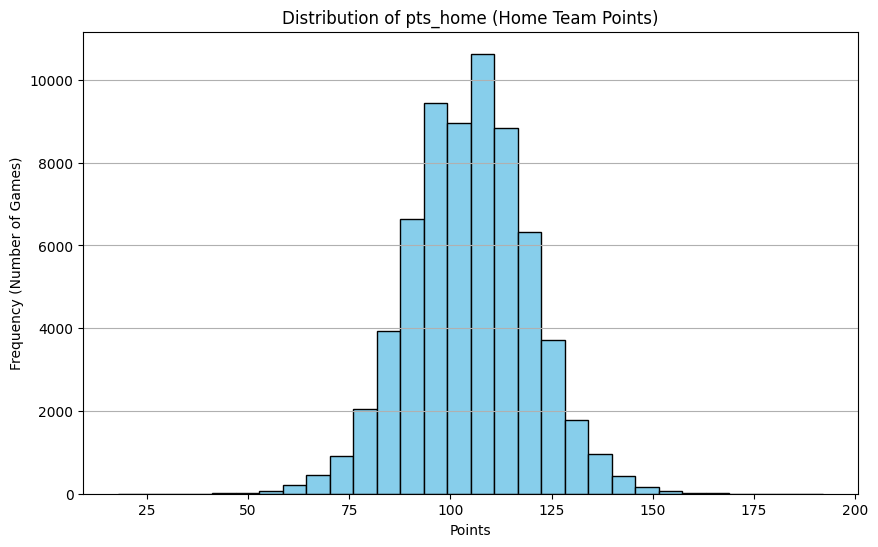

Outliers (Z-Score): 316
Outliers (IQR): 832
Outliers (Percentiles): 1128

------------------------ 5.2 Categorical Variables ------------------------
Mode: 'Boston Celtics' (4.76%)

Top 3 variables and their percentages:
team_name_home
Boston Celtics        4.759148
New York Knicks       4.459035
Los Angeles Lakers    4.053807

Smallest number of values to cover 50% of data: 14
These values are: ['Boston Celtics', 'New York Knicks', 'Los Angeles Lakers', 'Detroit Pistons', 'Philadelphia 76ers', 'Chicago Bulls', 'Phoenix Suns', 'Milwaukee Bucks', 'Atlanta Hawks', 'Houston Rockets', 'Cleveland Cavaliers', 'Portland Trail Blazers', 'Golden State Warriors', 'San Antonio Spurs']

--- Rare Categories Analysis (Under 1.0%) ---
Number of rare categories found: 68

List of rare categories and their percentages:
team_name_home
Oklahoma City Thunder                0.991743
Baltimore Bullets                    0.875964
Syracuse Nationals                   0.754090
Philadelphia Warriors            

In [47]:
print("------------------------------------------------ Q5 ------------------------------------------------")

# First of all - droping the duplications (both complete duplications and partial duplications) in order to not ruin our math...
df = df.drop_duplicates(subset=['game_id']) #

print("------------------------ 5.1 Numeric Variables ------------------------")

column1 = 'pts_home' # I'll choose a specific column for this task - pts_home (home team points)
mean = df[column1].mean() # average
median = df[column1].median() # median
std = df[column1].std() # standard deviation
mad = (df[column1] - mean).abs().mean() # MAD - Mean Absolute Deviation
min = df[column1].min() # minimum
max = df[column1].max() # maximum
q1 = df[column1].quantile(0.25) # (Q1 - 25%)
q3 = df[column1].quantile(0.75) # (Q3 - 75%)
iqr = q3 - q1 # interquartile range (IQR)
print(f"Metrics: Mean={mean:.2f}, Median={median}, Std={std:.2f}, MAD={mad:.2f}")
print(f"Range: Min={min}, Max={max}, Q1={q1}, Q3={q3}, IQR={iqr}")

skewness = df[column1].skew() # skewness
print(f"Skewness: {skewness:.2f}")

print("\nDistribution Plot:")
plt.figure(figsize=(10, 6))
df[column1].hist(bins=30, edgecolor='black', color='skyblue')
plt.title(f'Distribution of {column1} (Home Team Points)')
plt.xlabel('Points')
plt.ylabel('Frequency (Number of Games)')
plt.grid(axis='x')
plt.show()

# 3 methods of finding outliers:
z_scores = (df[column1] - mean) / std # calculate Z-scores
outliers_z = df[np.abs(z_scores) > 3].shape[0] # count Z-scores beyond 3 or -3
print(f"Outliers (Z-Score): {outliers_z}")

lower_bound = q1 - 1.5 * iqr # Lower bound for IQR
upper_bound = q3 + 1.5 * iqr # Upper bound for IQR
outliers_iqr = df[(df[column1] < lower_bound) | (df[column1] > upper_bound)].shape[0] # Count IQR outliers
print(f"Outliers (IQR): {outliers_iqr}")

p1 = df[column1].quantile(0.01) # 1st percentile
p99 = df[column1].quantile(0.99) # 99th percentile
outliers_perc = df[(df[column1] < p1) | (df[column1] > p99)].shape[0] # Count values outside 1%-99%
print(f"Outliers (Percentiles): {outliers_perc}")

print("\n------------------------ 5.2 Categorical Variables ------------------------")

 # again, I'll choose a specific column for this task - team_name_home
column2 = 'team_name_home'
freqs = df[column2].value_counts() # count frequencies (commonness)
freqs_pct = df[column2].value_counts(normalize=True) * 100 # convert to percentages
mode_val = freqs.index[0] # Most frequent value
mode_pct = freqs_pct.iloc[0] # Percentage of most frequent value
print(f"Mode: '{mode_val}' ({mode_pct:.2f}%)")

k = 3 # example input of *k* most common variables
top_k = freqs_pct.head(k)
print(f"\nTop 3 variables and their percentages:\n{top_k.to_string()}")

p = 50 # example input of *p*  - target percentage
cum_pct = freqs_pct.cumsum() # Cumulative sum of percentages
num_vals_for_p = (cum_pct <= p).sum() + 1 # Number of categories needed to reach 50%
vals_for_p = list(freqs.index[:num_vals_for_p]) # The categories themselves
print(f"\nSmallest number of values to cover {p}% of data: {num_vals_for_p}")
print(f"These values are: {vals_for_p}")

rare_threshold = 1.0 # I define rare as less than 1%.
rare_cats = freqs_pct[freqs_pct < rare_threshold] # Filter rare categories
print(f"\n--- Rare Categories Analysis (Under {rare_threshold}%) ---")
print(f"Number of rare categories found: {len(rare_cats)}")
print("\nList of rare categories and their percentages:")
print(rare_cats.to_string())
total_rare_pct = rare_cats.sum()
merged_column = df[column2].apply(lambda x: 'Other' if x in rare_cats.index else x)


**------------------------ 5.1 Numeric Variables Analysis ------------------------**

**Basic Statistics - Mean, Median, Std, MAD, Min/Max, Quantiles & IQR:**
For the home team points, the calculated average (mean) is 104.60, which is almost perfectly aligned with the median of 105.0.
Looking at the spread of the data, the standard deviation is 14.73 and the Mean Absolute Deviation (MAD) is 11.63. The Interquartile Range (IQR) is 19.0, meaning that the middle 50% of all games typically end with scores between 95.0 (Q1) and 114.0 (Q3).
The absolute minimum score in the dataset is 18.0, and the maximum score is 192.0 points.

**Skewness: Is the data skewed to one side?**
No, the data is not significantly skewed. The calculated skewness is -0.01. Since this value is practically zero, it indicates that the data is highly symmetrical and evenly balanced around the mean, without a long tail pulling to either the left or the right.

**Distribution:**
As seen in the generated histogram, the data follows a classic normal distribution shape (a bell curve). The vast majority of the games are clustered right around the center (100-110 points), and the frequencies drop off symmetrically and smoothly as the scores get higher or lower.

**Outlier Detection (Using the 3 1D Methods):**
I checked for outliers using the three different methods we learned, and got the following results:

Z-Score Method (values beyond 3 standard deviations): Identified 316 outliers.

IQR Fences Method (values outside Q1/Q3 ± 1.5*IQR): Identified 832 outliers.

Percentiles Method (values in the bottom 1% and top 1%): Identified 1,128 outliers.

As expected, the Percentiles method was the most aggressive, while the Z-score method was the most "forgiving". Looking at the extreme values we found earlier, the minimum of 18 points is likely a historical outlier (perhaps from a game before the shot-clock era or an aborted game), while the maximum of 192 points represents a rare multi-overtime game.

**------------------------ 5.2 Categorical Variables Analysis ------------------------**

**Frequencies. What is the mode? What percentage of the data does it occupy?**
The most frequent value in our categorical data is the "Boston Celtics". They occupy approximately 4.76% of the total games in the dataset.

**What are the K most common variables and what percentage of the data do they occupy?**
I chose K = 3 to observe the top three most common franchises in NBA history. These are:
Boston Celtics (4.76%)
New York Knicks (4.46%)
Los Angeles Lakers (4.05%)
Together, these top 3 variables occupy approximately 13.27% of the entire dataset. This makes sense contextually, as these are some of the oldest and most historic franchises in the league, meaning they have hosted more games overall.

**What is the smallest number of values needed to describe P percent of the data? What are those values?**
I set P = 50% to see how many teams it takes to account for half of all the games played. The calculation shows that we need the top 14 most frequent teams to cover 50% of the data.
These 14 values are: Boston Celtics, New York Knicks, Los Angeles Lakers, Detroit Pistons, Philadelphia 76ers, Chicago Bulls, Phoenix Suns, Milwaukee Bucks, Atlanta Hawks, Houston Rockets, Cleveland Cavaliers, Portland Trail Blazers, Golden State Warriors, and San Antonio Spurs.

**Rare categories? Do they contain information or can they be ignored? Can values be merged?**
I defined rare as any category occupying less than 1% of the data, and identified 68 rare categories.
Looking closely at the list, these categories do contain real information and should not just be ignored or deleted. They fall into three main groups:

Historical/Relocated Teams: Seattle SuperSonics, Syracuse Nationals, New Jersey Nets, Minneapolis Lakers.

International Teams: Teams that played NBA exhibition games (Real Madrid, **Tel Aviv Maccabi Elite**, FC Barcelona).

All Star Teams: Team LeBron, Team Giannis, etc.

Can they be ignored? No. Ignoring or deleting these rows means losing valid data points and actual games played, which would distort the overall dataset and reduce its historical accuracy.

Can they be merged? Yes, absolutely. Keeping 68 separate categories that each represent a tiny fraction of a percent will create unnecessary "noise" and high dimensionality for future machine learning models. We can merge these values by grouping them into a new, single category labeled "Other Teams" or "Historical/Exhibition Teams".

**------------------------ Discussion: Do the central tendency metrics represent the data well? ------------------------**
For this specific categorical variable - NO. the central metric (the mode) does not represent the data well.
Even though the "Boston Celtics" is the mode, it only accounts for 4.76% of the dataset. Because the NBA has 30 active teams that all play the same number of home games per season, the data is highly fragmented and distributed relatively evenly across many categories. Therefore, pointing to a single "most common" team does not give us a meaningful summary of the entire dataset.


------------------------------------------------ Q6 ------------------------------------------------
------------------------ 6.1 Numeric-Numeric ------------------------
Pearson (pts_home vs fg_pct_home): 0.680
Spearman (pts_home vs fg_pct_home): 0.667
Kendall (pts_home vs fg_pct_home): 0.487

Full Pearson Correlation Matrix:


,pts_home,fg_pct_home,ast_home,reb_home
pts_home,1.000000,0.679976,0.622267,0.190543
fg_pct_home,0.679976,1.000000,0.602074,-0.159230
ast_home,0.622267,0.602074,1.000000,0.097615
reb_home,0.190543,-0.159230,0.097615,1.000000


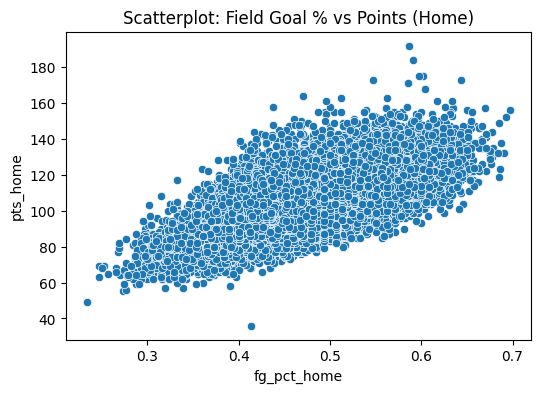


------------------------ 6.2 Categorical-Categorical ------------------------
Frequency Table (Win/Loss vs Point Bins):
pts_bins    Low  Medium   High
wl_home                       
L         13040    8382   3595
W          8974   14608  17041

Frequency Table (Percentages per Row):
pts_bins       Low    Medium      High
wl_home                               
L         0.521246  0.335052  0.143702
W         0.220909  0.359599  0.419491

Mean points by Win/Loss:
wl_home
L     97.802694
W    108.785417
Name: pts_home, dtype: float64

Cramer's V score: 0.348

------------------------ 6.3 Graphs ------------------------
Generating all 8 plots...


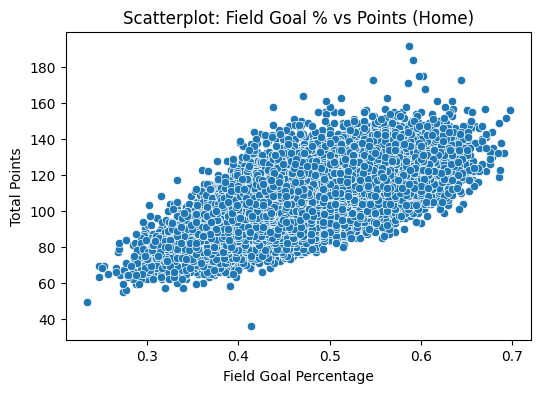

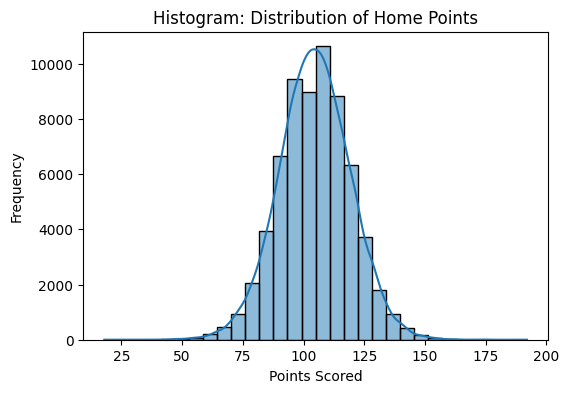

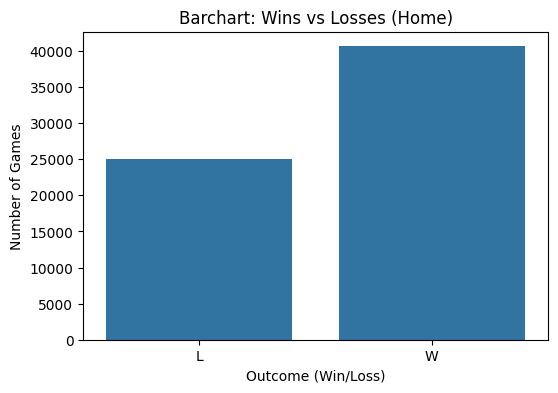

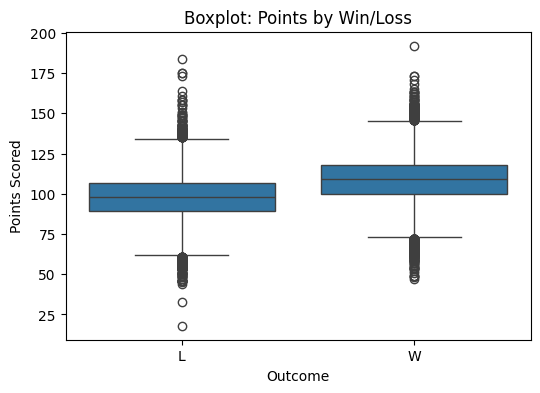

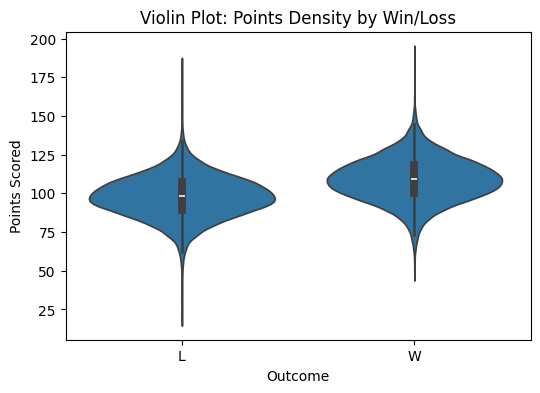

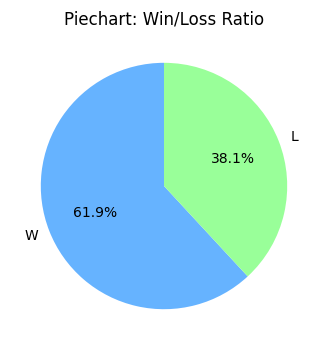

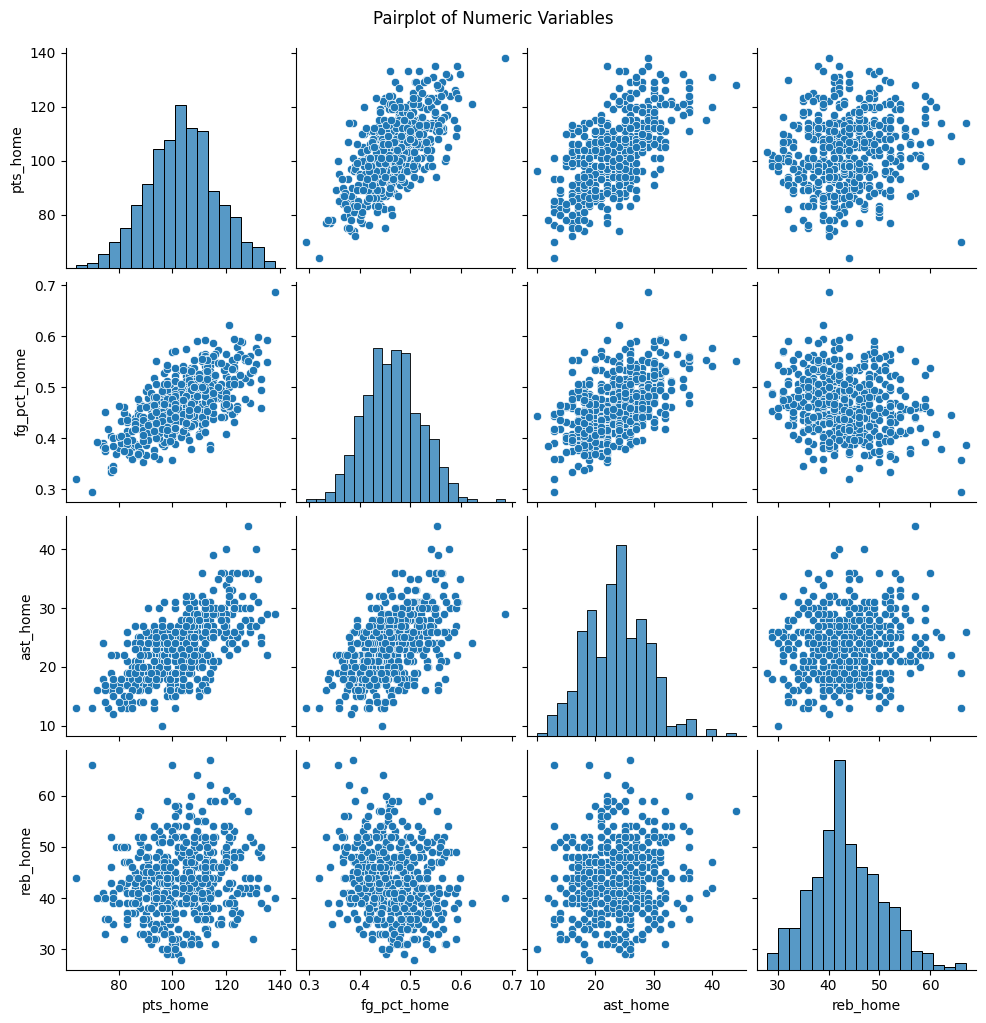

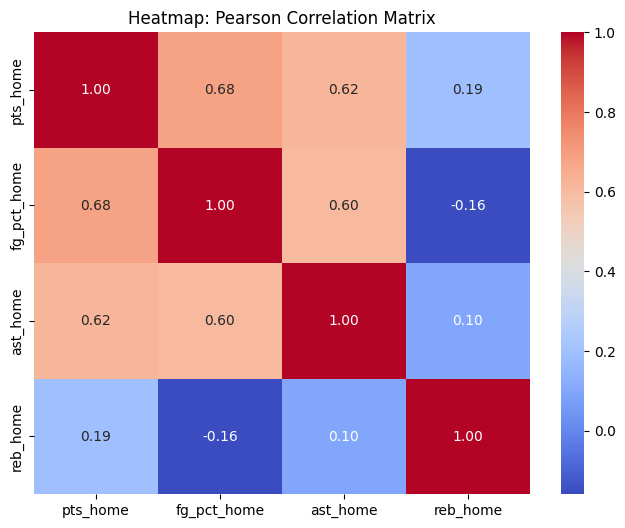


------------------------ Extra Bonus Graphs ------------------------


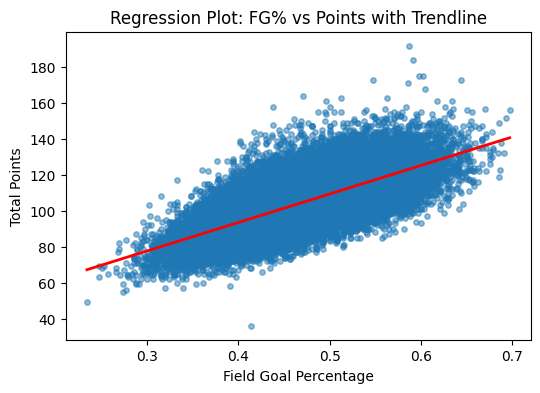

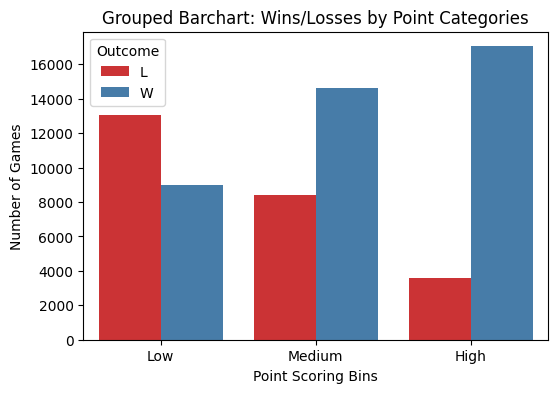

In [48]:
print("------------------------------------------------ Q6 ------------------------------------------------")

# just in case - droping the duplicates in case Q5 has not yet been run..
df = df.drop_duplicates(subset=['game_id'])

print("------------------------ 6.1 Numeric-Numeric ------------------------")
# Choosing logical numeric columns so the matrix makes sense
num_cols = ['pts_home', 'fg_pct_home', 'ast_home', 'reb_home']
df_num = df[num_cols].dropna() # droping NaNs so math works

corr_pearson = df_num.corr(method='pearson')
print(f"Pearson (pts_home vs fg_pct_home): {corr_pearson.loc['pts_home', 'fg_pct_home']:.3f}")

corr_spearman = df_num.corr(method='spearman')
print(f"Spearman (pts_home vs fg_pct_home): {corr_spearman.loc['pts_home', 'fg_pct_home']:.3f}")

corr_kendall = df_num.corr(method='kendall')
print(f"Kendall (pts_home vs fg_pct_home): {corr_kendall.loc['pts_home', 'fg_pct_home']:.3f}")

print(f"\nFull Pearson Correlation Matrix:")
display(corr_pearson)

plt.figure(figsize=(6,4))
sns.scatterplot(data=df_num, x='fg_pct_home', y='pts_home')
plt.title('Scatterplot: Field Goal % vs Points (Home)')
plt.show()

print("\n------------------------ 6.2 Categorical-Categorical ------------------------")
cat_col = 'wl_home' # Win/Loss category

# Binning: converting numeric points to categories (Low, Medium, High)
df['pts_bins'] = pd.qcut(df['pts_home'], q=3, labels=['Low', 'Medium', 'High']) # dividing to 3 categories
freq_table = pd.crosstab(df[cat_col], df['pts_bins'])  # Frequency Table 1
print(f"Frequency Table (Win/Loss vs Point Bins):\n{freq_table}")
freq_table_pct = pd.crosstab(df[cat_col], df['pts_bins'], normalize='index')  # Frequency Table 2
print(f"\nFrequency Table (Percentages per Row):\n{freq_table_pct}")

# Relationship between Categorical and Numerical
print("\nMean points by Win/Loss:")
print(df.groupby(cat_col)['pts_home'].mean())

# Cramer's V function
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = __builtins__.max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / __builtins__.min((kcorr-1), (rcorr-1)))

c_v = cramers_v(df[cat_col].dropna(), df['pts_bins'].dropna())
print(f"\nCramer's V score: {c_v:.3f}")


print("\n------------------------ 6.3 Graphs ------------------------")
print("Generating all 8 plots...")

# 1. Scatterplot - (already showed it in 6.1...)
plt.figure(figsize=(6,4))
sns.scatterplot(data=df_num, x='fg_pct_home', y='pts_home')
plt.title('Scatterplot: Field Goal % vs Points (Home)')
plt.xlabel('Field Goal Percentage')
plt.ylabel('Total Points')
plt.show()

# 2. Histogram
plt.figure(figsize=(6,4))
sns.histplot(df['pts_home'].dropna(), bins=30, kde=True)
plt.title('Histogram: Distribution of Home Points')
plt.xlabel('Points Scored')
plt.ylabel('Frequency')
plt.show()

# 3. Barchart
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='wl_home')
plt.title('Barchart: Wins vs Losses (Home)')
plt.xlabel('Outcome (Win/Loss)')
plt.ylabel('Number of Games')
plt.show()

# 4. Boxplot
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='wl_home', y='pts_home')
plt.title('Boxplot: Points by Win/Loss')
plt.xlabel('Outcome')
plt.ylabel('Points Scored')
plt.show()

# 5. Violin
plt.figure(figsize=(6,4))
sns.violinplot(data=df, x='wl_home', y='pts_home')
plt.title('Violin Plot: Points Density by Win/Loss')
plt.xlabel('Outcome')
plt.ylabel('Points Scored')
plt.show()

# 6. Piechart
plt.figure(figsize=(6,4))
df['wl_home'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#99ff99'])
plt.title('Piechart: Win/Loss Ratio')
plt.ylabel('') # Removes the column name from the side
plt.show()

# 7. Pairplot
# Sampling for performance
sns.pairplot(df_num.sample(500))
plt.suptitle('Pairplot of Numeric Variables', y=1.02)
plt.show()

# 8. Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_pearson, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap: Pearson Correlation Matrix')
plt.show()

print("\n------------------------ Extra Bonus Graphs ------------------------")

# Regression Plot
plt.figure(figsize=(6,4))
sns.regplot(data=df_num, x='fg_pct_home', y='pts_home',
            scatter_kws={'alpha':0.5, 's':15}, line_kws={'color':'red', 'linewidth':2})
plt.title('Regression Plot: FG% vs Points with Trendline')
plt.xlabel('Field Goal Percentage')
plt.ylabel('Total Points')
plt.show()

# Grouped Bar Chart
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='pts_bins', hue='wl_home', palette='Set1')
plt.title('Grouped Barchart: Wins/Losses by Point Categories')
plt.xlabel('Point Scoring Bins')
plt.ylabel('Number of Games')
plt.legend(title='Outcome')
plt.show()

**------------------------ 6.1 Numeric-Numeric ------------------------**

In this analysis, I examined the relationship between Home Points (pts_home) and Home Field Goal Percentage (fg_pct_home) using three different methods:

**Correlation:**
Pearson (=0.680): This coefficient shows a strong positive linear relationship between shooting accuracy and total points.

Spearman (=0.667): This rank-based correlation also indicates a strong positive association, confirming that as one variable increases, the other generally does as well.

Kendall (=0.487): While lower than the others, this score still represents a significant positive correlation based on the consistency of the data rankings.

The difference between these values stems from how each algorithm processes the data. Pearson measures the linear strength between the exact values, making it sensitive to the scale of the points. Spearman and Kendall are non-parametric and look at the "rank" or order of the data instead. Spearman is often higher than Kendall because it measures the distance between ranks, while Kendall focuses on the probability of the rankings being in the same order. The fact that all three are positive and relatively high confirms a reliable trend.

**Correlation Matrix:**
The Full Pearson Correlation Matrix provides a detailed look at how different game metrics interact.
We can see that pts_home has high correlations with fg_pct_home (0.680) and ast_home (0.622), suggesting these are key scoring drivers.
The correlation between points and rebounds (reb_home) is notably weaker at 0.191.
Interestingly, there is a slight negative correlation between field goal percentage and rebounds (-0.159).

**Scatter Plots:**
The Scatterplot visualizes the relationship between Field Goal % and Points for the home team.
A clear upward density is visible, indicating that as the shooting percentage improves, the total points scored tend to increase.
Most games are clustered between 0.35 and 0.6 FG%, with points typically falling between 80 and 140.

**What conclusions can be drawn about the correlation?**
The main conclusion is that shooting efficiency is a strong predictor of offensive success.
Since both Pearson and Spearman scores are high, the relationship is consistent and robust across the dataset.
Furthermore, the correlation matrix suggests that while assists are strongly linked to scoring, rebounding has a much smaller direct impact on the home team's total points.


**------------------------ 6.2 Categorical-Categorical ------------------------**

**Frequency Tables:**
I created two frequency tables to explore the relationship between the match outcome (Win/Loss) and the home team's scoring levels (Points Bins):

Absolute Table: The counts show that most losses (13,040) occur in the "Low" point bin, while the vast majority of wins (17,041) happen when the team scores in the "High" bin.

Percentage Table: This table shows the distribution of outcomes. For instance, while only 14.3% of losses occur in the "High" scoring bin, a significant 41.9% of all wins are achieved when the team scores "High." This clearly demonstrates that scoring more points increases the probability of a win.

**Cramer's V:**
The Cramer's V score is 0.348. In the context of categorical data, this score represents a moderate-to-strong association between the scoring bins and the game outcome. It confirms that the point category is a meaningful predictor of whether a team won or lost the game.
Binning and the Relationship between Categorical and Numerical:
To analyze this relationship, I used Binning to transform the continuous point data into three distinct categories: Low, Medium, and High.
To further prove the connection between the categorical result and the original numerical values, I calculated the Mean points by Win/Loss:
The average score for a Win (W) is 108.78 points.
The average score for a Loss (L) is 97.80 points.
This difference of nearly 11 points on average highlights the direct impact of offensive production on the final categorical outcome.

**What can be concluded from this info?**
The analysis leads to a clear conclusion: there is a significant positive relationship between the amount of points scored and the likelihood of winning. The frequency tables show a clear shift toward victory as teams move from "Low" to "High" scoring bins. Coupled with the Cramer's V score and the mean differences, we can state that higher point totals are strongly associated with a higher winning percentage for the home team.

**------------------------ 6.3 Graphs ------------------------**
The following visualizations provide a comprehensive overview of the home team's performance, scoring patterns, and the relationships between key game metrics.

1. Scatterplot: Field Goal % vs. Points (Home)
This plot shows a clear upward trend, indicating a strong positive relationship between shooting accuracy and total points scored. As the home team's field goal percentage increases, the point total consistently rises. This visually confirms the Pearson correlation of 0.68, proving that offensive efficiency is a primary driver of the final score.

2. Histogram: Distribution of Home Points
The distribution of home points follows a nearly normal (bell-shaped) curve. Most games result in a total score between 100 and 115 points, which represents the typical offensive output for a home team. Extreme scores, such as those below 75 or above 150, are statistically rare in this dataset.

3. Barchart: Wins vs. Losses (Home)
This chart clearly illustrates the home-court advantage. The number of wins (W) is significantly higher than the number of losses (L), with over 40,000 recorded victories. This suggests that the home environment plays a major role in a team's likelihood of success.


4. Boxplot: Points by Win/Loss
The boxplot demonstrates that winning games are associated with higher scoring. The median number of points for a win is approximately 110, while the median for a loss is closer to 98. Although there is some overlap in the interquartile ranges, the higher placement of the "W" box confirms that scoring more points is a key differentiator between winning and losing.

5. Violin Plot: Points Density by Win/Loss
This plot shows the density and "shape" of the scoring for both outcomes. The "win" violin is wider at higher point values, indicating a high concentration of games where high scoring led to victory. Conversely, the "loss" violin is wider at lower point values, showing that lower offensive production often results in a loss.


6. Piechart: Win/Loss Ratio
The piechart summarizes the overall performance of home teams, showing a 61.9% win rate compared to a 38.1% loss rate. This provides a clear, high-level view of the dataset, confirming that home teams win roughly two-thirds of their matchups.

7. Pairplot of Numeric Variables
The pairplot allows for a multi-variable comparison. It shows that both assists and field goal percentage have a strong linear relationship with points. However, the relationship between rebounds and points is much more scattered, suggesting that rebounding is a less direct predictor of scoring than shooting accuracy or playmaking.

8. Heatmap: Pearson Correlation Matrix
The heatmap provides a numerical summary of all relationships. The strong red colors between points, field goal percentage (0.68), and assists (0.62) highlight these as the most influential factors for scoring. The light blue color for rebounds (0.19) confirms it has the weakest linear impact on the home team's point total among the variables tested.



**Regression Plot: FG% vs Points with Trendline**
Description: This plot enhances the standard scatterplot by adding a linear regression line (the red trendline) through the data points, which are slightly transparent to show density.

Insight: The red line provides a clear visual representation of the positive trajectory between shooting efficiency and the total points scored. The distinct upward slope perfectly illustrates that higher field goal percentages reliably predict higher point totals.

Conclusion: This visual firmly supports the Pearson correlation score from Section 6.1. It acts as visual proof that a team's shooting accuracy directly dictates the expected trend of their offensive output.


**Grouped Barchart: Wins/Losses by Point Categories**
Description: This chart visualizes the categorical relationship between the team's scoring bins (Low, Medium, High) and the game outcome (Win in blue, Loss in red). This directly translates the frequency tables from Section 6.2 into a visual format.

Insight: The contrast between the categories is striking. In the "Low" scoring bin, the red loss bar clearly outnumbers the blue win bar. However, as the scoring moves to "Medium," wins take the lead. By the time we reach the "High" bin, wins overwhelmingly dominate the chart while losses drop to a minimum.

Conclusion: This chart acts as compelling visual proof that scoring volume is a decisive factor in winning. It confirms that categorizing a team's offensive output is a highly accurate way to predict their likelihood of securing a victory.


------------------------------------------------ Q7 ------------------------------------------------
('game_date' + 'team_id_home') - is it unique? True
Is the index unique? False
Is it time-based? True
Is it sorted chronologically? False
--> (Action taken: Dataset has been sorted by the time index)
Generating plot to analyze changes over time...


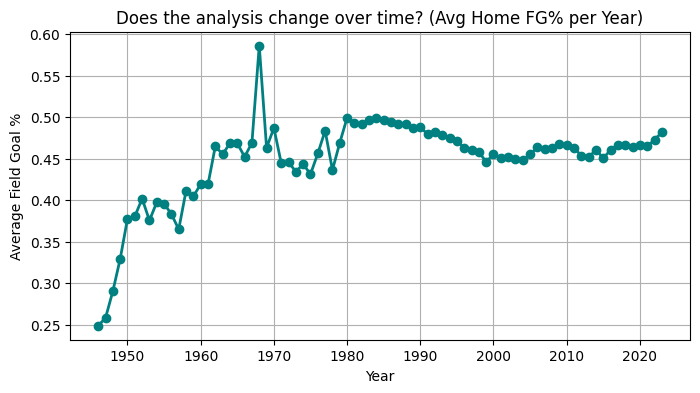

In [54]:
print("------------------------------------------------ Q7 ------------------------------------------------")

# as I previously said in 3.2 notes:
# "important insight here is that the date column- game_date, currently appears as plain text and not as a time format, so I might need to fix it, in case I analyse by time."
# exactly as I stated - now I'll need to convert the type to datetime in order to work with this data.
df['game_date'] = pd.to_datetime(df['game_date'])

# at this point I already know that: 'game_id' and 'game_date' - aren't unique (because I already tested it in 3.2...)
# since the is no real index - I'm going to make a mix of columns that together will form an index.
# composite (game_date + team_id_home)
composite_key = df['game_date'].astype(str) + "_" + df['team_id_home'].astype(str)
is_composite_unique = composite_key.is_unique
print(f"('game_date' + 'team_id_home') - is it unique? {is_composite_unique}")

df_idx = df.set_index('game_date')

print(f"Is the index unique? {df_idx.index.is_unique}")
print(f"Is it time-based? {isinstance(df_idx.index, pd.DatetimeIndex)}")

is_sorted = df_idx.index.is_monotonic_increasing
print(f"Is it sorted chronologically? {is_sorted}")
if not is_sorted:
    df_idx = df_idx.sort_index()
    print("--> (Action taken: Dataset has been sorted by the time index)")
print("Generating plot to analyze changes over time...")

plt.figure(figsize=(8, 4))
df_idx.groupby(df_idx.index.year)['fg_pct_home'].mean().plot(marker='o', color='teal', linewidth=2)
plt.title('Does the analysis change over time? (Avg Home FG% per Year)')
plt.xlabel('Year')
plt.ylabel('Average Field Goal %')
plt.grid(True)
plt.show()

**------------------------ 7 ------------------------**

Before randomly assigning an index, I conducted a brief EDA to find a column that could serve as a perfect unique identifier for each row. As noted earlier, standalone columns like game_id or game_date - are **not** unique.
To solve this, I created a composite Key by combining game_date and team_id_home. As the output shows ('game_date' + 'team_id_home') this created a perfectly unique identifier, since a team cannot play two home games on the exact same day.

However, it seems the assignment specifically requires a time-based index to analyze trends over time. Therefore, I chose to set game_date as the index. While it successfully serves as a time format, it is unfortunately not unique. I proceeded with this approach in order to fulfill the time-related questions of the assignment.

**Is the index unique?**
False. As expected, because multiple NBA games are played simultaneously on the same calendar day, the game_date index contains duplicate values and is not unique.

**Is it time based?**
Yes, game_date is indeed time based. By converting the original plain text date column into datetime objects using pd.to_datetime(), the index is now officially recognized by pandas as a time-based DatetimeIndex.

**Is it sorted chronologically?**
Not initially.. The check revealed that the dataset was not sorted chronologically. Because time-series analysis requires data to flow forward in time, I programmatically applied sort_index() to fix this issue. The dataset is now perfectly sorted from the earliest games to the most recent ones.

**Does the analysis change over time?**
Yes, significantly. To demonstrate this, I generated a line plot tracking the Average Home Field Goal Percentage (fg_pct_home) per year from the late 1940s to the 2020s.
The visual evidence is striking:
In the early days of the league (late 1940s to mid-1960s), there was a massive, rapid increase in shooting accuracy, climbing from roughly 25% to around 45%.
The Peak: There is a distinct, sharp spike just before 1970, where the average abruptly shoots up to nearly 58-59% before dropping back down.
After this anomaly, the average stabilized near 50% during the 1980s, followed by a gradual decline during the defensive-heavy era of the late 1990s and early 2000s (dropping back to around 45%).
In recent years, the trend is slightly climbing upwards again, approaching 47-48%.
This clearly proves that the statistical analysis and game metrics are not static; they continuously evolve over time.


**------------------------ 8 ------------------------**

As a huge basketball fan, I specifically chose this dataset because I wanted to see if the cliches and narratives we hear on NBA broadcasts actually hold up to mathematical scrutiny. Here is what the data revealed:

**Three Central Insights:**

**1. The "Home Court Advantage" is Mathematically Huge:**
As a fan, you always hear commentators say "role players shoot better at home" and talk about crowd energy. The data proves this isn't just a psychological myth - it's a MASSIVE statistical advantage. As calculated in the 6.3 Piechart - home teams win a staggering 61.9% of their games. Furthermore, Section 6.2 (Means analysis) proved that offensive rhythm directly dictates the outcome: home teams average 108.78 points in a win, compared to just 97.80 points in a loss.

**2. Spacing and Passing > Crashing the Boards:**
 There is an old-school basketball mentality that dominating rebounds is the key to scoring. However, the Pearson Correlation Matrix in Section 6.1 shattered this idea. Rebounds (reb_home) have a very weak correlation with total points (0.19). Instead, playmaking (ast_home = 0.62) and shooting efficiency (fg_pct_home = 0.68) are the true drivers. This perfectly reflects the modern "Pace and Space" NBA, where ball movement and the "extra pass" create efficient offense much more than simply relying on offensive rebounds.

**3. The NBA is a Living, Evolving Game:**
The time-series analysis proved that NBA basketball continuously evolves. Shooting efficiency saw a massive climb from the late 1940s to the 1970s (peaking sharply near 58%), followed by a decline during the heavy defensive era in the 80s and early 2000s, and is currently trending upwards again. This proves that statistical benchmarks change depending on the historical era.



**Biases and Risks**

**Historical Era Bias:**
Analyzing total points or shooting percentages across all years without context is dangerous. For example, the 3-point line was only introduced in 1979! A team's pts_home or fg_pct_home in 1965 cannot be fairly compared to the 2023 Golden State Warriors, because the geometric spacing and rules of the game have completely changed.

**Confirmation Bias (Ignoring the Defense):**
Throughout the  EDA (especially in Q6), we focused heavily on home team offensive metrics. This creates a risk of ignoring the away team's defensive impact. A high home FG% might just be the result of facing a terrible defensive team, not necessarily a brilliant offensive night.



**Potential Failure Points for ML Models**
If we were to train a Machine Learning model on this dataset to predict game outcomes (Win/Loss), two major failure points could occur:

Data Leakage: If we feed the model post-game statistics like Total Points (pts_home) or Field Goals Made (fgm_home) to predict if the team won (wl_home), the model will achieve a very high percentage of accuracy, but will be completely useless in the real world. You cannot use features that are only known after the game ends to predict the outcome before the game starts.

Concept Drift (Time-Based Failure): Because the game evolves (as proven in Question 7), an ML model trained heavily on data from the 1990s (an era of low scoring and physical defense) will fail miserably if deployed to predict games in 2024 (an era of fast pace and high 3-point volume). The underlying relationships between the features change over time.

**What I Learned & Did My Opinion Change?**
Technically, I learned how to effectively manipulate large datasets, handle time-series data, and translate raw correlation numbers into meaningful visual graphs.
my opinion definitely changed regarding the statistical weight of specific metrics. While I knew shooting was important, seeing the math prove that passing and assists (ast_home) are vastly more important to the final score than rebounding (reb_home) was an eye-opener.




**------------------------ 9 ------------------------**

**Time Dependence & External Knowledge**
As a basketball fan, I know the data doesn't exist in a vacuum.
**The 2004 Hand-Checking Rule:** In Q7, we saw offensive ratings climb after the early 2000s. Externally, we know the NBA banned perimeter hand-checking in 2004, freeing up guards and directly causing this scoring spike.
**The 2020 COVID Bubble:** In Q6, we established a 61.9% home-win rate. If we filter for the 2020 Orlando Bubble (no fans), this advantage disappears, proving "home court" is heavily driven by crowd psychology.


**Engineering Feature**
Raw shooting percentage (`fg_pct_home`) is outdated because it treats 2-pointers and 3-pointers equally. I would engineer **Effective Field Goal Percentage (eFG%)**. Instead of using a raw math formula, the logic simply adds bonus weight to made 3-pointers before dividing by total shot attempts. This properly rewards teams for modern 3-point shooting (a stylistic shift heavily driven by players like Stephen Curry) and is a vastly superior predictor of offensive success.


**Hypothesis Testing**
As basketball fans, we constantly hear complaints that referees favor the home team by giving them more foul calls and free throws. Since our dataset includes Free Throws Attempted for both the home team (`fta_home`) and the away team (`fta_away`), we could easily test this myth. By comparing the average free throw attempts of the home team versus the away team across thousands of games, we could definitively prove if "home-court advantage" is actually driven by referee bias or just better playing.


**Proposals for Further Research**
here are 2 interesting topics I would might have add to the assignment (because they are interesting to me):

**The Fatigue Factor:**
We can actually analyze the impact of fatigue without needing any external data. By sorting the dataset by team and calculating the time difference between consecutive `game_date` entries, we can engineer a "Days of Rest" feature. This would allow us to analyze exactly how playing "back-to-back" games impacts a team's shooting efficiency and overall win probability.

**Superstar Availability:**
Basketball is a superstar-driven league. I would cross-reference team stats with injury reports to measure how win probability plummets when a top scorer sits out.